<a href="https://colab.research.google.com/github/data-by-ck/Milwaukee-Data-Analysis-2026/blob/main/milwaukee_data_analysis_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milwaukee Open Data Project: City Dataset Trends (2026)

In [6]:
import pandas as pd

# This is the direct link to the Milwaukee Dataset Catalog CSV
# As of 2026, this is the most reliable way to get the list
catalog_url = "https://data.milwaukee.gov/dataset/dataset-catalog/resource/9a4bf009-869f-49b7-81de-c03c386c433a/download/dataset-catalog.csv"

# One line to read the whole thing!
df = pd.DataFrame()
try:
  df = pd.read_csv(catalog_url)
  print("Success! Catalog downloaded.")
  print(f"Total datasets found: {len(df)}")
  # Display the first 5 rows to see what data we have
  display(df.head())
except Exception as e:
  print(f"Error: {e}")


Success! Catalog downloaded.
Total datasets found: 188


,_id,Title,Description,Dataset ID,Tags,License,Organization,Groups,Source,Version,Author,Author Email,Maintainer,Maintainer Email,Created,Last Updated,Topic,Dataset URL
0,1,"2016 Nov 6, State Senator District 7","2016 Nov 6, State Senator District 7\r\n\r\n__...",2016-nov-6-state-senator-district-7,"Ballot,Election,State Senator,Vote",cc-by,Election Commission,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-11-12T23:08:18.201897,2025-02-14T21:07:15.095223,NaN,https://data.milwaukee.gov/dataset/2016-nov-6-...
1,2,"2016 Nov 8 , Representative of the Assembly Di...",Representative of the Assembly District 17 Rac...,representative-of-the-assembly-district-17-rac...,"Ballot,District 17,Election,Representative of ...",cc-by,Election Commission,Elections & Campaign,NaN,NaN,NaN,NaN,NaN,NaN,2018-10-24T20:24:02.513224,2025-02-14T21:02:32.359429,Elections & Campaign,https://data.milwaukee.gov/dataset/representat...
2,3,"2016 Nov 8, County Clerk",County Clerk Race by Ward Nov 8 2016\r\n\r\n__...,county-clerk-race-by-ward-nov-8-2016,"Ballot,County Clerk,Election,Vote,Voting",cc-by,Election Commission,Elections & Campaign,NaN,NaN,NaN,NaN,NaN,NaN,2018-10-24T19:56:26.577552,2025-02-14T21:11:35.748770,Elections & Campaign,https://data.milwaukee.gov/dataset/county-cler...
3,4,"2016 Nov 8, County Treasurer",County Treasurer Race by Ward Nov 8 2016\r\n\r...,county-treasurer-race-by-ward-nov-8-2016,"Ballot,County Treasurer,Election,Vote,Voting",cc-by,Election Commission,Elections & Campaign,NaN,NaN,NaN,NaN,NaN,NaN,2018-10-24T19:55:12.533001,2025-02-14T21:11:27.133399,Elections & Campaign,https://data.milwaukee.gov/dataset/county-trea...
4,5,"2016 Nov 8, District Attorney",District Attorney Race by Ward Nov 8 2016\r\n\...,district-attorney-race-by-ward-nov-8-2016,"Ballot,District Attorney,Election,Vote,Voting",cc-by,Election Commission,Elections & Campaign,NaN,NaN,NaN,NaN,NaN,NaN,2018-10-24T19:57:46.676682,2025-02-14T21:11:45.510281,Elections & Campaign,https://data.milwaukee.gov/dataset/district-at...


In [9]:
# This counts how many datasets each Oarganization has published
if not df.empty:
  dept_counts = df['Organization'].value_counts()
  print("Top Milwaukee Departments by Data Volume:")
  print(dept_counts.head(10))


Top Milwaukee Departments by Data Volume:
Organization
Election Commission                               72
Information Technology and Management Division    25
Fire and Police Commission                        20
Department of City Development                    13
Assessor's Office                                  9
Milwaukee Police Department                        9
Department of Public Works                         9
Milwaukee Fire Department                          6
External Organizations                             5
Office of the Comptroller                          4
Name: count, dtype: int64


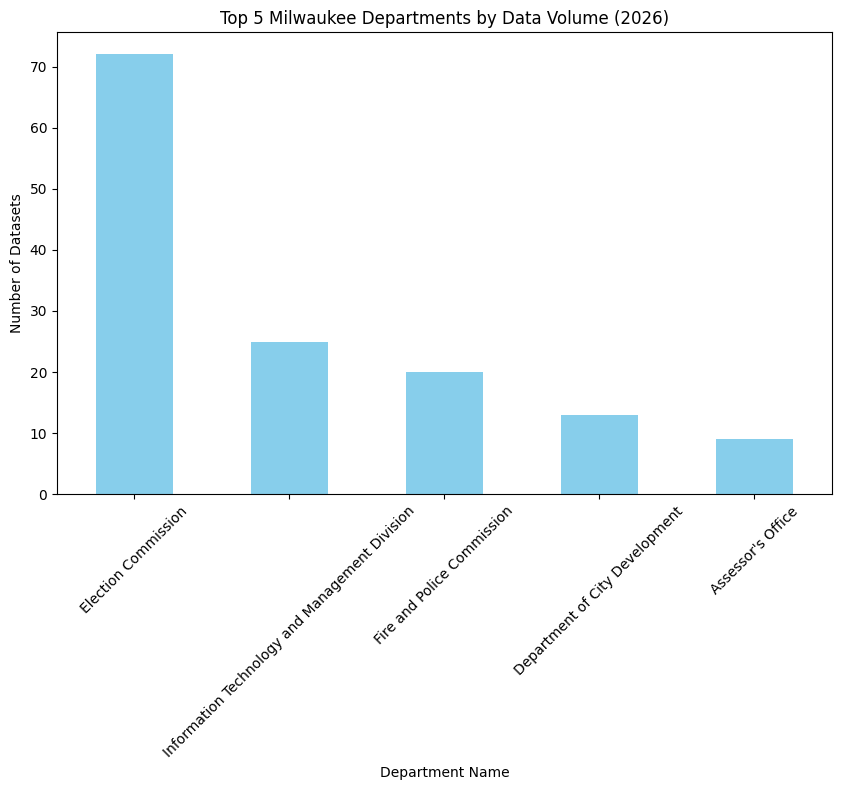

In [12]:
import matplotlib.pyplot as plt

# 1. Prepare the data (Top 5 departments)
top_depts = df['Organization'].value_counts().head(5)

# 2. Create the Bar Chart
plt.figure(figsize=(10,6))
top_depts.plot(kind='bar', color='skyblue')

# 3. Add Lables (The professional touch)
plt.title('Top 5 Milwaukee Departments by Data Volume (2026)')
plt.xlabel('Department Name')
plt.ylabel('Number of Datasets')
plt.xticks(rotation=45)

# 4. Show it!
plt.show()


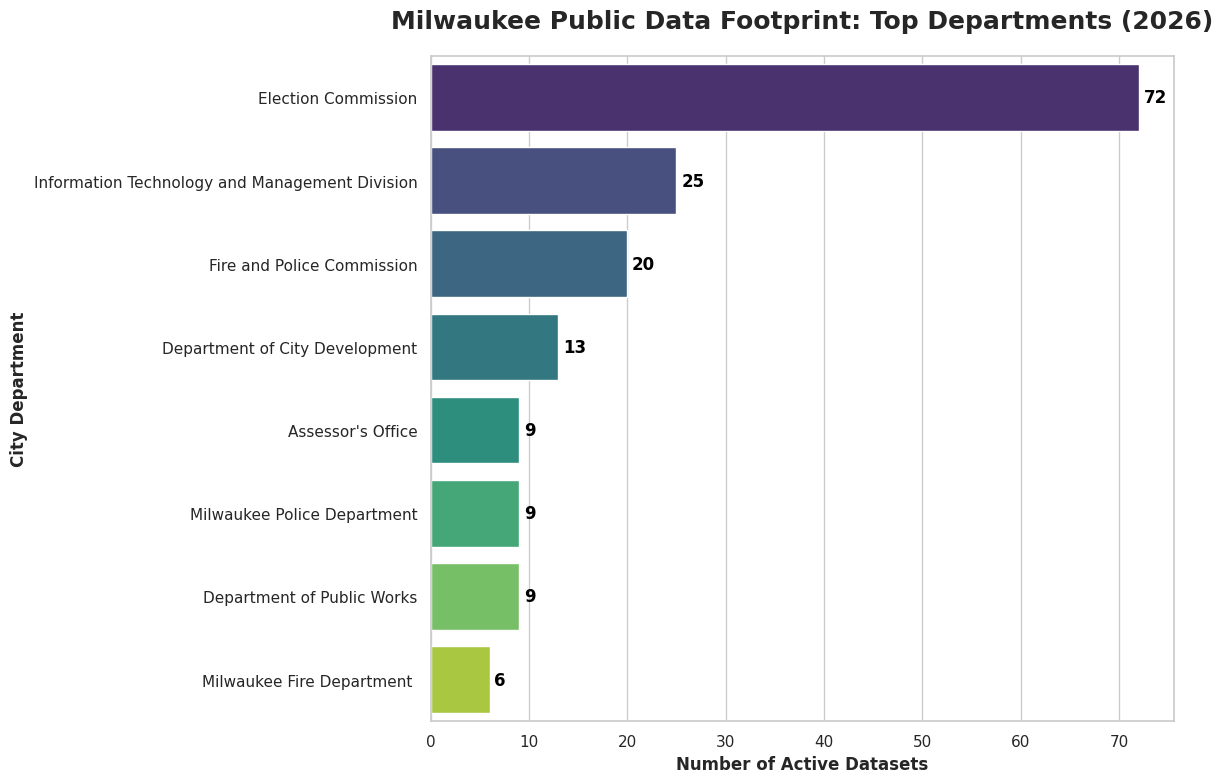

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 2. Get the Top 8 Departments (gives a good sense of scale)
top_depts = df['Organization'].value_counts().head(8)

# 3. Create a horizontal bar chart (easier to read department names)
ax = sns.barplot(
    x=top_depts.values,
    y=top_depts.index,
    hue=top_depts.index,
    palette="viridis",
    legend=False
)

# 4. Add the "Professional Polish"
plt.title('Milwaukee Public Data Footprint: Top Departments (2026)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Active Datasets', fontsize=12, fontweight='bold')
plt.ylabel('City Department', fontsize=12, fontweight='bold')

# 5. Add data labels to the end of each bar
for i, v in enumerate(top_depts.values):
  ax.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

# 6. Final layout adjustment
plt.tight_layout()
plt.show()